In [476]:
import MGLensing
import numpy as np
import matplotlib.pyplot as plt


In [477]:
def cov2corr(cov):
    """
    Convert a covariance matrix into a correlation matrix
    input:
        cov: numpy.array with dim:(N,N)
    returns:
        corr: numpy.array with dim:(N,N)
    """
    sig = np.sqrt(cov.diagonal())
    return cov/np.outer(sig, sig)


In [478]:
### Load and collect the data for likelihood
#npzfile = np.load("../Biases_parametrization/Data_storage_fR.npz")
npzfile = np.load("/home/c2042999/PCA_project/Parameter_inference_ESS/Data_storage_ESS_partial_Sigma1.npz")
npzfile_GR = np.load("Data_storage_GR.npz")

C_ell_data_mock = [npzfile['C_ell_data'],npzfile['ell_data'],npzfile['z'],npzfile['Binned_distribution_source'],\
                    npzfile['Binned_distribution_lens'],20,1478.5,13]

Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]

L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])

gauss_invcov_rotated = np.matrix(npzfile_GR['Inverse_cov'])

z = npzfile['z']

In [479]:
# ~~~~~~~~~~~~~~~~~~~~~~~~ Get Covariance - full ~~~~~~~~~~~~~~~~~~~~~~~~

covfile = np.genfromtxt("/home/c2042999/PCA_project/Parameter_inference_GR/Y1_3x2pt_clusterN_clusterWL_cov")

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
SRD_compare = shear_SRD[:540,:540].copy()

idx = 0

bins_SRD = int(len(SRD_compare)/(len(C_ell_data_mock[0])/13))
print("bins_SRD", bins_SRD)
print(int(len(C_ell_data_mock[0])/13))

for j in range(int(len(C_ell_data_mock[0])/13)):
    for i in range(bins_SRD):
        if i >= 13:
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 0)
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 1)
            idx += 1

covariance_uncut = np.matrix(SRD_compare)

Mat_plot_2 = np.linalg.inv(np.linalg.cholesky(covariance_uncut[:195,:195]))


bins_SRD 20
27


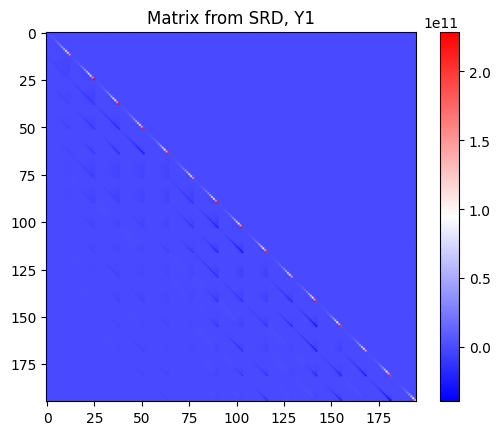

In [480]:

plt.imshow((Mat_plot_2), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")
plt.colorbar()
plt.show()

In [481]:
#np.savetxt("/home/c2042999/MGLensing/ini_files/pca/Cholesky_inv_SRD.txt", Mat_plot_2)

In [482]:
print(npzfile['ell_data'])

[  23.59970561   32.85941027   45.75230138   63.70391509   88.6991184
  123.5015712   171.95929751  239.43015228  333.37422663  464.17869231
  646.30628639  899.89442158 1252.98173181   23.59970561   32.85941027
   45.75230138   63.70391509   88.6991184   123.5015712   171.95929751
  239.43015228  333.37422663  464.17869231  646.30628639  899.89442158
 1252.98173181   23.59970561   32.85941027   45.75230138   63.70391509
   88.6991184   123.5015712   171.95929751  239.43015228  333.37422663
  464.17869231  646.30628639  899.89442158 1252.98173181   23.59970561
   32.85941027   45.75230138   63.70391509   88.6991184   123.5015712
  171.95929751  239.43015228  333.37422663  464.17869231  646.30628639
  899.89442158 1252.98173181   23.59970561   32.85941027   45.75230138
   63.70391509   88.6991184   123.5015712   171.95929751  239.43015228
  333.37422663  464.17869231  646.30628639  899.89442158 1252.98173181
   23.59970561   32.85941027   45.75230138   63.70391509   88.6991184
  123.501

In [483]:
L_ch_inv_MGLensing = np.loadtxt("/home/c2042999/MGLensing/ini_files/pca/Cholesky_inv.txt")
print(L_ch_inv_MGLensing.shape)

(195, 195)


In [484]:
Cov_MGLensing = np.loadtxt("/home/c2042999/MGLensing/ini_files/pca/Covariance_MGLensing")
print(Cov_MGLensing.shape)

(195, 195)


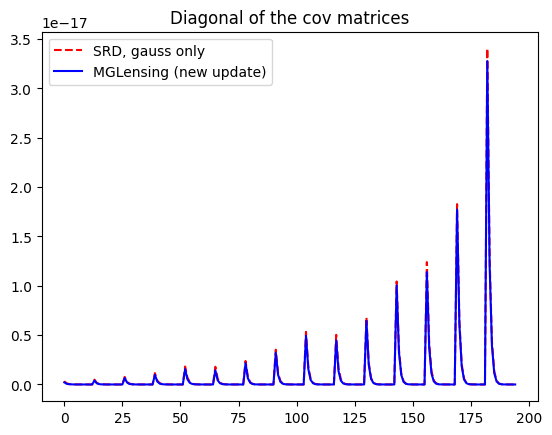

In [485]:

plt.plot((np.diag(covariance_uncut[:195,:195])), "r--", label="SRD, gauss only")
plt.plot((np.diag(Cov_MGLensing)), "b", label="MGLensing (new update)")
plt.title("Diagonal of the cov matrices")

#plt.yscale("log")
plt.legend()
#plt.plot([15*13,15*13],[1e-25,1e-10], "k--")
#plt.plot([15*13 + 7*13,15*13 + 7*13],[1e-25,1e-10], "k--")


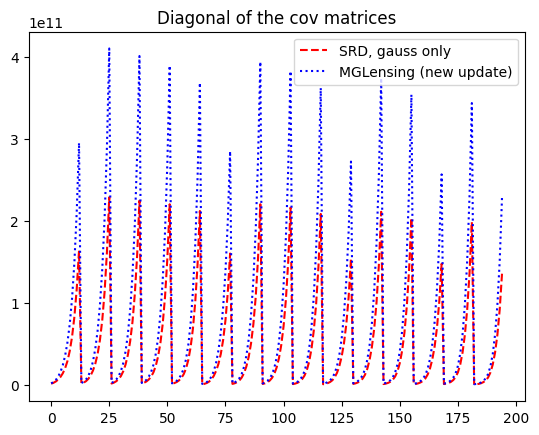

In [486]:

plt.plot((np.diag(Mat_plot_2)), "r--", label="SRD, gauss only")
plt.plot((np.diag(np.linalg.inv(np.linalg.cholesky(Cov_MGLensing)))), "b:", label="MGLensing (new update)")
plt.title("Diagonal of the cov matrices")

#plt.yscale("log")
plt.legend()
#plt.plot([15*13,15*13],[1e-25,1e-10], "k--")
#plt.plot([15*13 + 7*13,15*13 + 7*13],[1e-25,1e-10], "k--")


(195, 195)


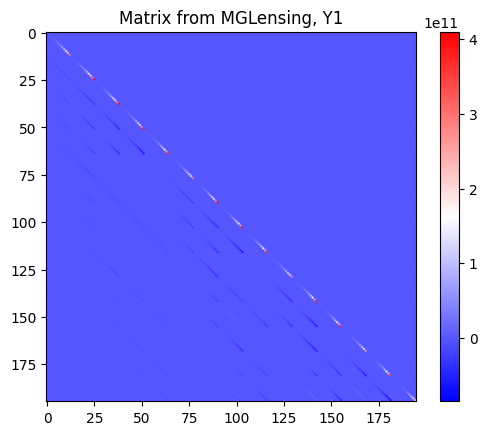

In [487]:
print(L_ch_inv_MGLensing.shape)

matrix_filtered_rows = L_ch_inv_MGLensing[kept_indx[:131], :]
matrix_final_3 = matrix_filtered_rows[:, kept_indx[:131]]

plt.imshow((L_ch_inv_MGLensing), origin='upper',  cmap='bwr')
plt.title("Matrix from MGLensing, Y1")
plt.colorbar()
plt.show()

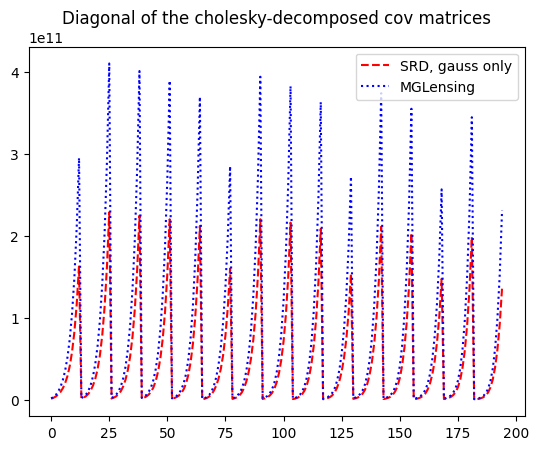

In [488]:

plt.plot(np.diag((Mat_plot_2)), "r--", label="SRD, gauss only")
plt.plot(np.diag((L_ch_inv_MGLensing)), "b:", label="MGLensing")
plt.title("Diagonal of the cholesky-decomposed cov matrices")

#plt.yscale("log")
plt.legend()
#plt.plot([15*13,15*13],[1e-25,1e-10], "k--")
#plt.plot([15*13 + 7*13,15*13 + 7*13],[1e-25,1e-10], "k--")


(351, 351)


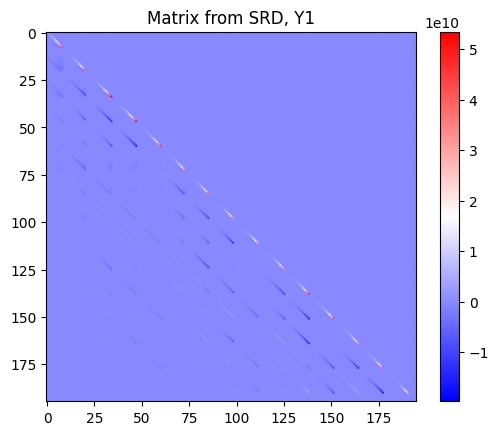

In [489]:
print(L_choleski_inv.shape)
Mat_plot = L_choleski_inv[:195,:195]

matrix_filtered_rows = Mat_plot[kept_indx[:131], :]
matrix_final = matrix_filtered_rows[:, kept_indx[:131]]

plt.imshow((Mat_plot), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")

plt.colorbar()
plt.show()

(131, 131)


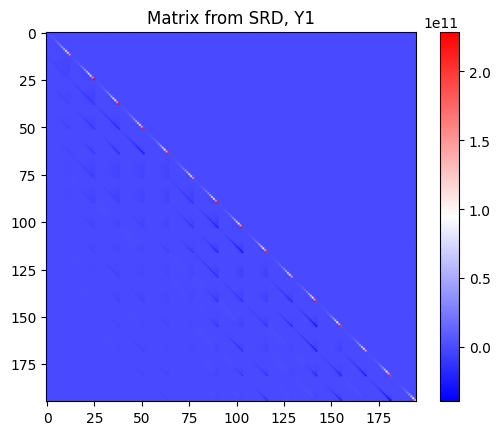

In [490]:
Mat_plot_2 = np.linalg.inv(np.linalg.cholesky(covariance_uncut[:195,:195]))

matrix_filtered_rows = Mat_plot_2[kept_indx[:131], :]
matrix_final_2 = matrix_filtered_rows[:, kept_indx[:131]]

print(matrix_final_2.shape)
plt.imshow((Mat_plot_2), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")


plt.colorbar()
plt.show()

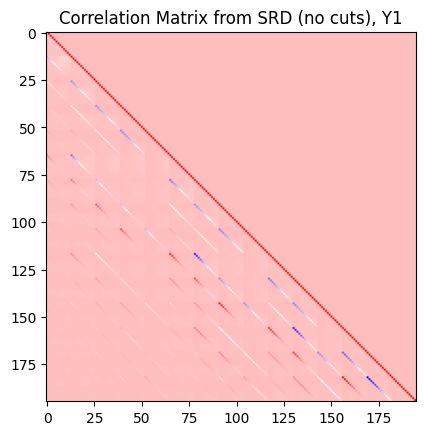

In [491]:
plt.title("Correlation Matrix from SRD (no cuts), Y1")

plt.imshow(cov2corr(Mat_plot_2), origin='upper',  cmap='bwr')


In [492]:
are_close = np.allclose(matrix_final_2, matrix_final, atol=1e-2, rtol=1e-2)
print("are the matrices close enough? ", are_close)


are the matrices close enough?  True


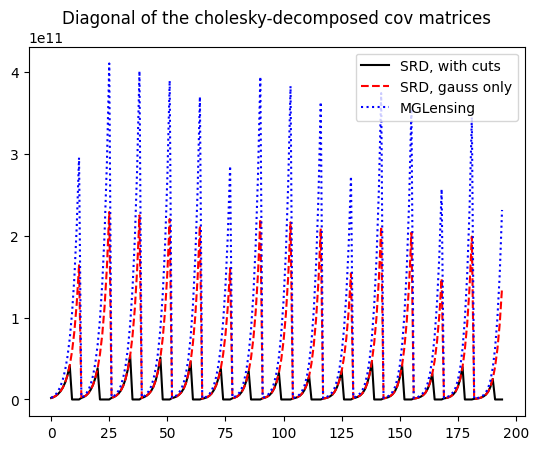

In [493]:

plt.plot(np.diag((Mat_plot)), "k", label="SRD, with cuts")
plt.plot(np.diag((Mat_plot_2)), "r--", label="SRD, gauss only")
plt.plot(np.diag((L_ch_inv_MGLensing)), "b:", label="MGLensing")
plt.title("Diagonal of the cholesky-decomposed cov matrices")

#plt.yscale("log")
plt.legend()
#plt.plot([15*13,15*13],[1e-25,1e-10], "k--")
#plt.plot([15*13 + 7*13,15*13 + 7*13],[1e-25,1e-10], "k--")


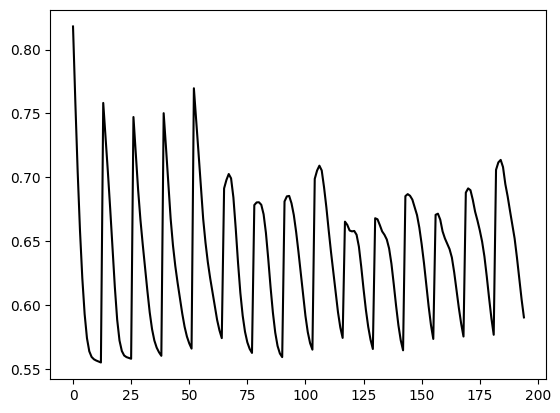

In [494]:

plt.plot(np.diag((Mat_plot_2))/np.diag((L_ch_inv_MGLensing)), "k")
#plt.plot(np.diag((matrix_final))/np.diag((matrix_final_3)), "r--")
#plt.semilogy(np.diag((matrix_final_3)), "b:")

#plt.plot([15*13,15*13],[1e-25,1e-10], "k--")
#plt.plot([15*13 + 7*13,15*13 + 7*13],[1e-25,1e-10], "k--")


In [495]:
## Compare covariance
Cov_inv_MGLensing = np.loadtxt("/home/c2042999/MGLensing/ini_files/pca/Invcov_MGLensing.txt")


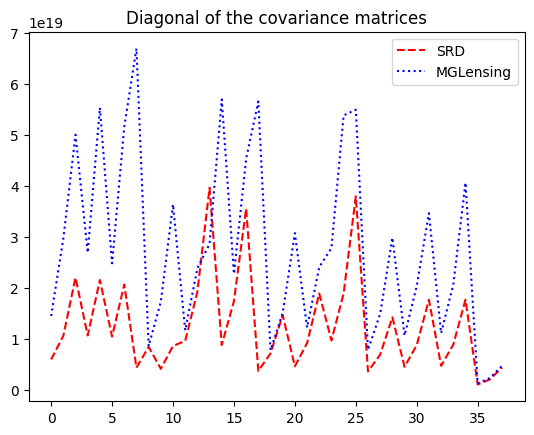

In [496]:

plt.plot(np.diag((covmatrix_final)), "r--", label="SRD")
plt.plot(np.diag((Cov_inv_MGLensing)), "b:", label="MGLensing")
plt.title("Diagonal of the covariance matrices")

#plt.yscale("log")
plt.legend()
#plt.plot([15*13,15*13],[1e-25,1e-10], "k--")
#plt.plot([15*13 + 7*13,15*13 + 7*13],[1e-25,1e-10], "k--")


(38, 38)


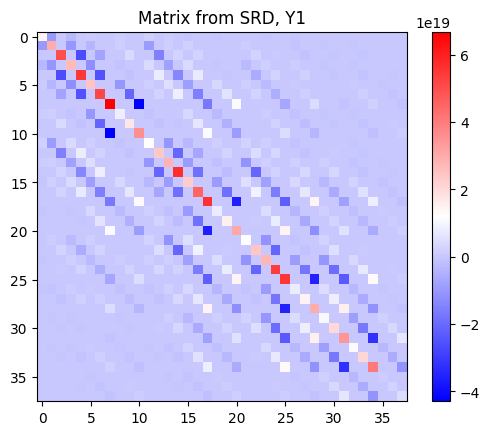

In [497]:
plt.imshow((Cov_inv_MGLensing), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")
print(Cov_inv_MGLensing.shape)

plt.colorbar()
plt.show()

(38, 38)


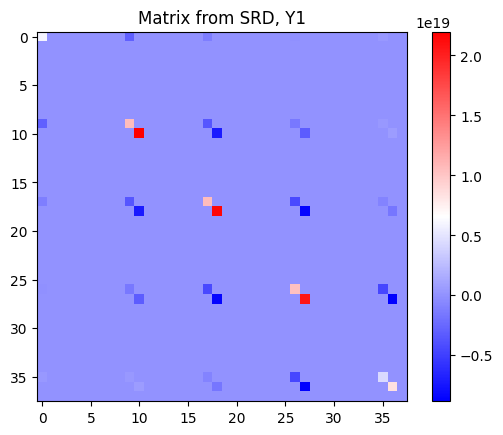

In [498]:
cov_totest = gauss_invcov_rotated[:195,:195]
matrix_filtered_rows = cov_totest[kept_indx[:38], :]
covmatrix_final = matrix_filtered_rows[:, kept_indx[:38]]
print(covmatrix_final.shape)


plt.imshow((covmatrix_final), origin='upper',  cmap='bwr')
plt.title("Matrix from SRD, Y1")


plt.colorbar()
plt.show()

In [499]:
print(C_ell_data_mock[0].shape)
print(C_ell_data_mock[1].shape)


(351,)
(351,)


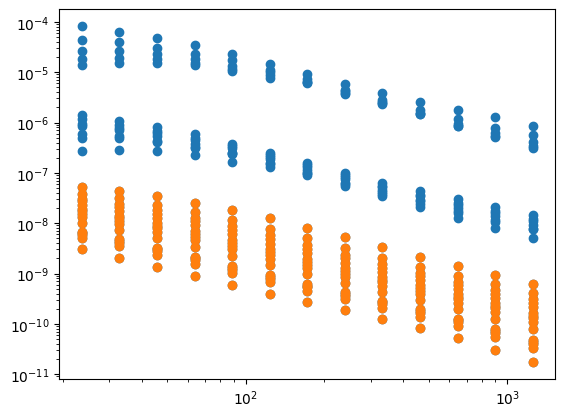

In [500]:
plt.scatter(C_ell_data_mock[1], C_ell_data_mock[0])
plt.scatter(C_ell_data_mock[1][:195], C_ell_data_mock[0][:195])
plt.xscale("log")
plt.yscale("log")

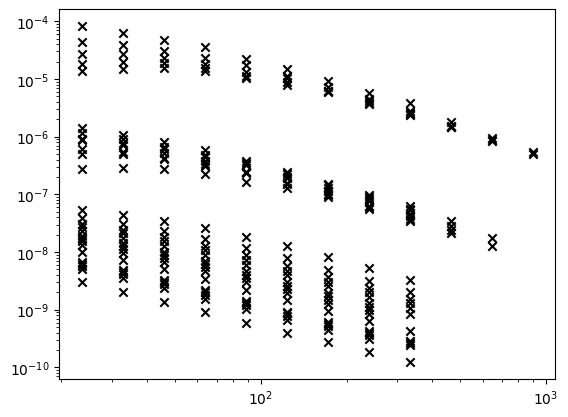

In [501]:
## Plot to check 3x2pt data

ex_indx = []
kept_indx = []

for i in range(len(C_ell_data_mock[1])):
    if np.any(L_choleski_inv[i] != 0.0):
        kept_indx.append(i)
        plt.scatter(C_ell_data_mock[1][i],C_ell_data_mock[0][i], color="k", marker="x")

ex_indx = [e for e in range(351) if e not in kept_indx]


plt.xscale("log")
plt.yscale("log")

In [502]:
for j in range(len(npzfile['Binned_distribution_lens'])):
        for k in range(len(npzfile['Binned_distribution_lens'])):
            if k > j:
                break
            print(k,j)

0 0
0 1
1 1
0 2
1 2
2 2
0 3
1 3
2 3
3 3
0 4
1 4
2 4
3 4
4 4


In [503]:
print(np.log(1.7*1e-9*10**10))
print(np.sqrt(2.5265*1e-8))

2.833213344056216
0.00015894967757123637


In [504]:
print(ex_indx)
print(len(kept_indx))
print(C_ell_data_mock[1][ex_indx])
cuts = [470,334,470, 470,470, 470,334,334,334,470,470,470,470,470, 470, 470, 470,470,647,647,900,900,470,647,900,1253,1253]
cuts_WL = [470,334,470, 470,470, 470,334,334,334,470,470,470,470,470, 470]
max_WL: [470, 334, 470, 334, 470,
                470, 470, 334, 470,
                470, 334, 470,
                470, 470,
                470]

cuts_WL_linear = [32,46,46, 46,46, 46,64,64,64,64,64,64,64,64, 64]

max_WL: [20, 46, 46, 64, 64,
                46, 46, 64, 64,
                46, 64, 64,
                64, 64,
                64]

max_WL: [20, 32, 46, 46, 64,
                46, 46, 64, 64,
                46, 64, 64,
                64, 64,
                64]

max_WL: [45, 60, 60, 85, 85,
                60, 60, 85, 85,
                60, 85, 85,
                85, 85,
                85]

[9, 10, 11, 12, 21, 22, 23, 24, 25, 35, 36, 37, 38, 48, 49, 50, 51, 61, 62, 63, 64, 74, 75, 76, 77, 86, 87, 88, 89, 90, 99, 100, 101, 102, 103, 112, 113, 114, 115, 116, 126, 127, 128, 129, 139, 140, 141, 142, 152, 153, 154, 155, 165, 166, 167, 168, 178, 179, 180, 181, 191, 192, 193, 194, 204, 205, 206, 207, 217, 218, 219, 220, 230, 231, 232, 233, 244, 245, 246, 257, 258, 259, 271, 272, 284, 285, 295, 296, 297, 298, 309, 310, 311, 323, 324, 337, 350]
254
[ 464.17869231  646.30628639  899.89442158 1252.98173181  333.37422663
  464.17869231  646.30628639  899.89442158 1252.98173181  464.17869231
  646.30628639  899.89442158 1252.98173181  464.17869231  646.30628639
  899.89442158 1252.98173181  464.17869231  646.30628639  899.89442158
 1252.98173181  464.17869231  646.30628639  899.89442158 1252.98173181
  333.37422663  464.17869231  646.30628639  899.89442158 1252.98173181
  333.37422663  464.17869231  646.30628639  899.89442158 1252.98173181
  333.37422663  464.17869231  646.30628639  8

In [505]:
#print(C_ell_data_mock[1])
#print(C_ell_data_mock[1][ex_indx])

for i in range(len(ex_indx)):
    if C_ell_data_mock[1][ex_indx[i]] <= C_ell_data_mock[1][ex_indx[i-1]]:
        if i ==0:
            print(C_ell_data_mock[1][ex_indx[i-1]])
        else:
            print(C_ell_data_mock[1][ex_indx[i-1]-1])

1252.9817318061569
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
899.89442158401
